<a href="https://colab.research.google.com/github/Deepti0107/EDA_Project/blob/main/Project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#                             **Aerial Object Classification Using Deep Learning**

**github link** :

**Problem Statement** :
The objective of this project is to build a deep learning model that can automatically classify aerial objects from images into predefined categories. The system uses Convolutional Neural Networks (CNN) to analyze image features and accurately predict the class of the object. This helps in applications like surveillance, defense systems, and automated monitoring.

**Libraries Used** :NumPy
Pandas
Matplotlib
TensorFlow/Keras
OS
Zipfile

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/classification_dataset-20260405T150928Z-1-001.zip"
extract_path = "/content/classification_dataset"

# Extract
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Extraction Done")

# Check structure
print(os.listdir(extract_path))

✅ Extraction Done
['classification_dataset']


In [6]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(224,224,3)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(2, activation='softmax')  # ✅ match 2 classes
])

In [7]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │    11,944,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,963,522 (45.64 MB)

 Trainable params: 11,963,522 (45.64 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

In [10]:
# Correct dataset path after extraction
base_path = "/content/classification dataset/classification_dataset"

train_path = base_path + "/train"
val_path = base_path + "/valid"
test_path = base_path + "/test"

In [11]:
import os

print (os.listdir('/content'))

['.config', 'classification_dataset', 'drive', 'sample_data']


In [12]:
print(os.listdir('/content/classification_dataset'))

['classification_dataset']


In [13]:
train_path ='/content/classification_dataset/classification_dataset/train'
val_path = '/content/classification_dataset/classification_dataset/valid'
test_path = '/content/classification_dataset/classification_dataset/test'

In [14]:
import tensorflow as tf
# Load datasets properly
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=(224,224),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_path,
    image_size=(224,224),
    batch_size=32
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=(224,224),
    batch_size=32
)

print(train_ds.class_names)

Found 2662 files belonging to 2 classes.
Found 442 files belonging to 2 classes.
Found 215 files belonging to 2 classes.
['bird', 'drone']


In [15]:
# show current working directory and top-level content
!pwd
!ls -la /content

# list anything that looks like "classification" (case-sensitive)
!ls -la "/content" | grep -i classification || true

# recursively search for a folder named 'classification_dataset' (may take a moment)
!find /content -maxdepth 3 -type d -iname "*classification_dataset*" -print


/content
total 24
drwxr-xr-x 1 root root 4096 Apr 16 14:55 .
drwxr-xr-x 1 root root 4096 Apr 16 14:52 ..
drwxr-xr-x 3 root root 4096 Apr 16 14:55 classification_dataset
drwxr-xr-x 4 root root 4096 Apr  2 13:31 .config
drwx------ 5 root root 4096 Apr 16 14:55 drive
drwxr-xr-x 1 root root 4096 Apr  2 13:31 sample_data
drwxr-xr-x 3 root root 4096 Apr 16 14:55 classification_dataset
/content/classification_dataset
/content/classification_dataset/classification_dataset


In [16]:
from pathlib import Path
import tensorflow as tf
import os

# Correct base path found from the output
base_path = Path("/content/classification_dataset/classification_dataset")

train_path = base_path / "train"
val_path   = base_path / "valid"
test_path  = base_path / "test"

for name, p in [("Train", train_path), ("Val", val_path), ("Test", test_path)]:
    print(f"**{name}**: {p} -> exists: {p.exists()}")


**Train**: /content/classification_dataset/classification_dataset/train -> exists: True
**Val**: /content/classification_dataset/classification_dataset/valid -> exists: True
**Test**: /content/classification_dataset/classification_dataset/test -> exists: True


In [17]:
!pip install albumentations opencv-python

In [18]:
import cv2
import os
from albumentations import (
    HorizontalFlip, VerticalFlip, RandomBrightnessContrast,
    Rotate, Blur, Compose
)

In [19]:
transform = Compose([
    HorizontalFlip(p=0.5),
    VerticalFlip(p=0.3),
    Rotate(limit=30, p=0.5),
    RandomBrightnessContrast(p=0.5),
    Blur(blur_limit=3, p=0.3)
])

In [20]:
input_folder = "/content/dataset/images"
output_folder = "/content/augmented_images"

os.makedirs(output_folder, exist_ok=True)

In [21]:
!ls /content

augmented_images  classification_dataset  drive  sample_data


In [23]:
!ls /content/drive/MyDrive

 classification_dataset-20260405T150928Z-1-001.zip  'Colab Notebooks'
 classification_dataset-20260408T153748Z-3-001.zip


In [24]:
!unzip "/content/drive/MyDrive/classification_dataset-20260405T150928Z-1-001.zip" -d /content/dataset

Archive:  /content/drive/MyDrive/classification_dataset-20260405T150928Z-1-001.zip
  inflating: /content/dataset/classification_dataset/test/drone/foto04467_png.rf.266b50f45ea47fd2888f5cb1bf2f7e1a.jpg  
  inflating: /content/dataset/classification_dataset/test/drone/pic_885_jpg.rf.8ba6e230f039420d39ad78c04ed40f05.jpg  
  inflating: /content/dataset/classification_dataset/test/drone/pic_421_jpg.rf.2ab51daa79aa245fc95a44086612b409.jpg  
  inflating: /content/dataset/classification_dataset/test/drone/pic_1060_jpg.rf.d00ccddcc08a3f38a736d8a8434aadf6.jpg  
  inflating: /content/dataset/classification_dataset/test/drone/pic_176_JPG.rf.8260eed4a50f974fcd228bd162fc060e.jpg  
  inflating: /content/dataset/classification_dataset/test/drone/pic_653_jpg.rf.285709934373ca3da9c5567337a53804.jpg  
  inflating: /content/dataset/classification_dataset/test/drone/pic_904_jpg.rf.35cb7678508bf522304e5d7e52a90535.jpg  
  inflating: /content/dataset/classification_dataset/test/drone/pic_797_jpg.rf.53edd77f1

In [25]:
input_folder = "/content/dataset/classification_dataset/train"

In [26]:
import cv2
import os
from albumentations import (
    HorizontalFlip, VerticalFlip, RandomBrightnessContrast,
    Rotate, Blur, Compose
)

transform = Compose([
    HorizontalFlip(p=0.5),
    VerticalFlip(p=0.3),
    Rotate(limit=30, p=0.5),
    RandomBrightnessContrast(p=0.5),
    Blur(blur_limit=3, p=0.3)
])

input_folder = "/content/dataset/classification_dataset/train"
output_folder = "/content/augmented_images"

os.makedirs(output_folder, exist_ok=True)

for root, dirs, files in os.walk(input_folder):
    for filename in files:
        if filename.endswith((".jpg", ".png", ".jpeg")):

            class_name = os.path.basename(root)  # bird / drone
            class_output = os.path.join(output_folder, class_name)
            os.makedirs(class_output, exist_ok=True)

            img_path = os.path.join(root, filename)
            image = cv2.imread(img_path)

            for i in range(3):
                augmented = transform(image=image)
                aug_image = augmented["image"]

                new_filename = f"{filename.split('.')[0]}_aug_{i}.jpg"
                cv2.imwrite(os.path.join(class_output, new_filename), aug_image)

print("Augmentation Completed ✅")

Augmentation Completed ✅


In [27]:
!ls /content/augmented_images

bird  drone


Found 2662 files belonging to 2 classes.
Found 442 files belonging to 2 classes.
Found 215 files belonging to 2 classes.
Class names: ['bird', 'drone']


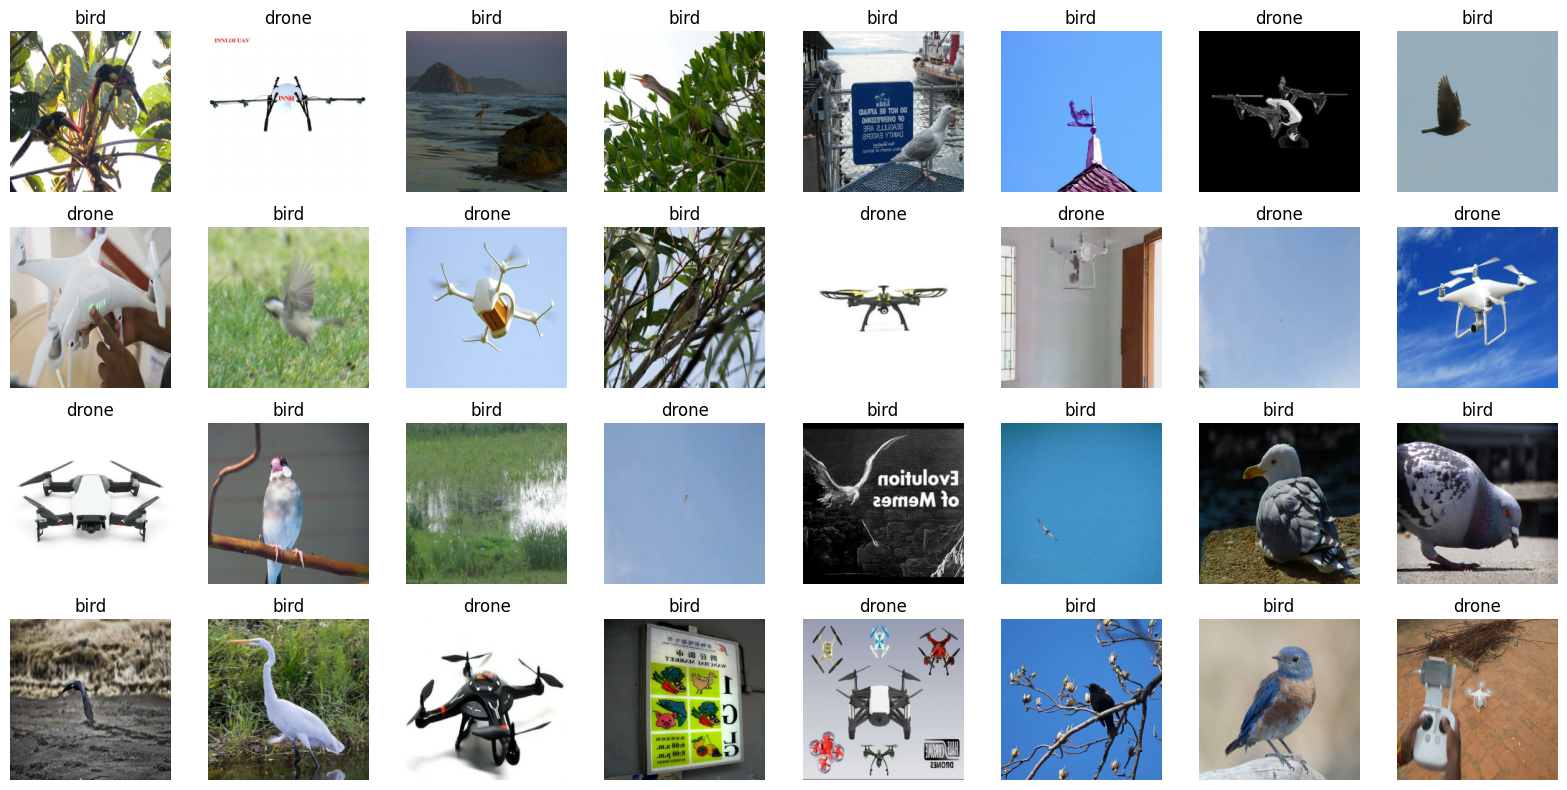

In [28]:
from pathlib import Path
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os

base_path = Path("/content/classification_dataset/classification_dataset")
train_path = base_path / "train"
val_path   = base_path / "valid"
test_path  = base_path / "test"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

# Load raw datasets (keep these objects to access class_names)
raw_train = tf.keras.utils.image_dataset_from_directory(
    str(train_path),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=True
)

raw_val = tf.keras.utils.image_dataset_from_directory(
    str(val_path),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

raw_test = tf.keras.utils.image_dataset_from_directory(
    str(test_path),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

# Save class names before transforming
class_names = raw_train.class_names
print("Class names:", class_names)

# Apply normalization and performance transforms to create datasets for training
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = raw_train.map(lambda x, y: (normalization_layer(x), y)).cache().prefetch(buffer_size=AUTOTUNE)
val_ds   = raw_val.map(lambda x, y: (normalization_layer(x), y)).cache().prefetch(buffer_size=AUTOTUNE)
test_ds  = raw_test.map(lambda x, y: (normalization_layer(x), y)).prefetch(buffer_size=AUTOTUNE)

# Display one batch of images and labels using the stored class_names
images, labels = next(iter(train_ds))
fig, axes = plt.subplots(4, 8, figsize=(16, 8))
axes = axes.flatten()
for img, lbl, ax in zip(images[:32], labels[:32], axes):
    ax.imshow(img.numpy())
    cls_idx = int(np.argmax(lbl))
    ax.set_title(class_names[cls_idx])
    ax.axis('off')
plt.tight_layout()
plt.show()


In [34]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
import numpy as np
import os

NUM_CLASSES = len(class_names)
INPUT_SHAPE = IMG_SIZE + (3,)

# --- Data augmentation (applied on-the-fly)
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.08),
], name="data_augmentation")

# --- Built model with MobileNetV2 backbone
base_model = tf.keras.applications.MobileNetV2(
    input_shape=INPUT_SHAPE,
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # freeze backbone initially

inputs = layers.Input(shape=INPUT_SHAPE)
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)  # optional, safe with Rescaling already applied
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = models.Model(inputs, outputs, name="mobilenetv2_transfer")

# --- Compile
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

model.summary()

# --- Compute class weights (optional but recommended for imbalance)
# Provide counts as integers; here using your printed counts
train_counts = {'bird': 1414, 'drone': 1248}
total = sum(train_counts.values())
class_weight = {}
for i, cls in enumerate(class_names):
    # inverse frequency
    class_weight[i] = total / (NUM_CLASSES * train_counts[cls])
print("Class weights:", class_weight)

# --- Callbacks
checkpoint_path = "best_model.h5"
cb = [
    callbacks.ModelCheckpoint(checkpoint_path, monitor='val_accuracy', save_best_only=True, verbose=1),
    callbacks.EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

# --- Train (stage 1: train top layers)
EPOCHS_STAGE1 = 10
history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_STAGE1,
    class_weight=class_weight,
    callbacks=cb
)

# --- Fine-tune: unfreeze some of the backbone
base_model.trainable = True
# Optionally unfreeze only the top layers
for layer in base_model.layers[:-50]:
    layer.trainable = False

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

EPOCHS_STAGE2 = 10
history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_STAGE2,
    class_weight=class_weight,
    callbacks=cb
)

# --- Evaluate on test set
test_loss, test_acc, test_auc = model.evaluate(test_ds)
print(f"Test loss: {test_loss:.4f}  Test accuracy: {test_acc:.4f}  Test AUC: {test_auc:.4f}")

# --- Save final model (if not already saved by checkpoint)
model.save("final_model.keras")


Model: "mobilenetv2_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_2 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_2 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,260,546 (8.62 MB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

...


Epoch 1: finished saving model to best_model.h5
84/84 ━━━━━━━━━━━━━━━━━━━━ 179s 2s/step - accuracy: 0.5026 - auc: 0.4963 - loss: 0.8315 - val_accuracy: 0.6131 - val_auc: 0.6462 - val_loss: 0.6868 - learning_rate: 1.0000e-04
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5079 - auc: 0.5054 - loss: 0.7807
Epoch 2: val_accuracy improved from 0.61312 to 0.66968, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
84/84 ━━━━━━━━━━━━━━━━━━━━ 219s 2s/step - accuracy: 0.5195 - auc: 0.5186 - loss: 0.7645 - val_accuracy: 0.6697 - val_auc: 0.7255 - val_loss: 0.6823 - learning_rate: 1.0000e-04
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5094 - auc: 0.5055 - loss: 0.7678
Epoch 3: val_accuracy improved from 0.66968 to 0.67195, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
84/84 ━━━━━━━━━━━━━━━━━━━━ 187s 2s/step - accuracy: 0.5135 - auc: 0.5143 - loss: 0.7595 - val_accuracy: 0.6719 - val_auc: 0.7536 - val_loss: 0.6776 - learning_rate: 1.0000e-04
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5232 - auc: 0.5387 - loss: 0.7400
Epoch 4: val_accuracy did not improve from 0.67195
84/84 ━━━━━━━━━━━━━━━━━━━━ 189s 2s/step - accuracy: 0.5199 - auc: 0.5323 - loss: 0.7433 - val_accuracy: 0.5475 - val_auc: 0.6491 - val_loss: 0.6735 - learning_rate: 1.0000e-04
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5417 - auc: 0.5546 - loss: 0.7219
Epoch 5: val_accuracy did not improve from 0.67195
84/84 ━━━━━━━━━━━━━━━━━━━━ 145s 2s/step - accuracy: 0.5237 - auc: 0.5438 - loss: 0.7301 - val_accuracy: 0.6606 - val_auc: 0.7375 - val_loss: 0.6686 - learning_rate: 1.0000e-04
Epoch 6/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5452 - auc: 0.5573 - loss: 0.7208
Epoch 6: val_accuracy improved


Epoch 6: finished saving model to best_model.h5
84/84 ━━━━━━━━━━━━━━━━━━━━ 175s 2s/step - accuracy: 0.5511 - auc: 0.5586 - loss: 0.7191 - val_accuracy: 0.6900 - val_auc: 0.7584 - val_loss: 0.6640 - learning_rate: 1.0000e-04
Epoch 7/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5332 - auc: 0.5516 - loss: 0.7212
Epoch 7: val_accuracy did not improve from 0.69005
84/84 ━━━━━━━━━━━━━━━━━━━━ 168s 2s/step - accuracy: 0.5263 - auc: 0.5419 - loss: 0.7263 - val_accuracy: 0.6516 - val_auc: 0.7158 - val_loss: 0.6602 - learning_rate: 1.0000e-04
Epoch 8/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5217 - auc: 0.5508 - loss: 0.7144
Epoch 8: val_accuracy did not improve from 0.69005
84/84 ━━━━━━━━━━━━━━━━━━━━ 147s 2s/step - accuracy: 0.5255 - auc: 0.5476 - loss: 0.7168 - val_accuracy: 0.6855 - val_auc: 0.7600 - val_loss: 0.6557 - learning_rate: 1.0000e-04
Epoch 9/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5585 - auc: 0.5779 - loss: 0.7064
Epoch 9: val_accuracy did not 

KeyboardInterrupt: 

In [35]:
model

<Functional name=mobilenetv2_transfer, built=True>

In [36]:
import os

print(os.listdir("/content"))

['.config', 'best_model.h5', 'classification_dataset', 'dataset', 'drive', 'augmented_images', 'sample_data']


In [37]:
import os
print(os.listdir("/content/classification_dataset"))

['classification_dataset']


In [38]:
test_dir = "/content/classification_dataset/classification_dataset/test"

In [39]:
import os
print(os.listdir("/content/classification_dataset/classification_dataset"))

['test', 'valid', 'train']


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


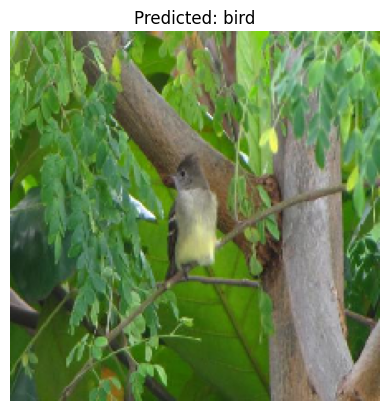

In [40]:
import os
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

test_dir = "/content/classification_dataset/classification_dataset/test"

class_names = os.listdir(test_dir)

# pick one image
img_path = test_dir + "/" + class_names[0] + "/" + os.listdir(test_dir + "/" + class_names[0])[0]

img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

prediction = model.predict(img_array)
predicted_class = class_names[np.argmax(prediction)]

plt.imshow(img)
plt.title(f"Predicted: {predicted_class}")
plt.axis('off')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step


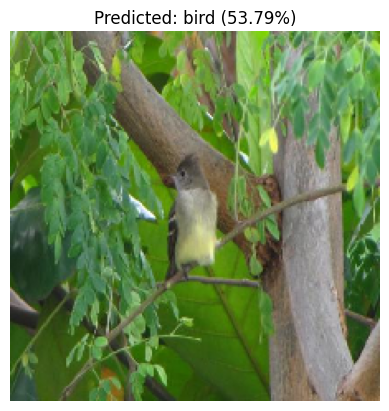

In [41]:
prediction = model.predict(img_array)
confidence = np.max(prediction) * 100
predicted_class = class_names[np.argmax(prediction)]

plt.imshow(img)
plt.title(f"Predicted: {predicted_class} ({confidence:.2f}%)")
plt.axis('off')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step


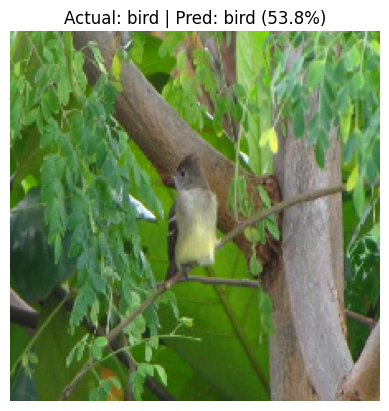

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step


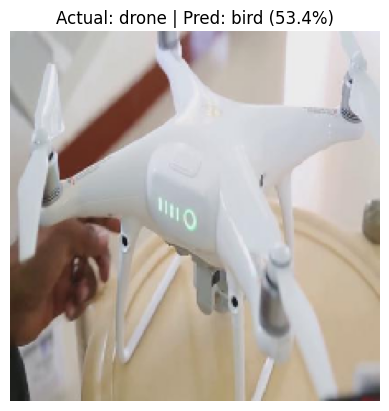

In [42]:
for class_folder in class_names:
    img_name = os.listdir(test_dir + "/" + class_folder)[0]
    img_path = test_dir + "/" + class_folder + "/" + img_name

    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    prediction = model.predict(img_array)
    confidence = np.max(prediction) * 100
    predicted_class = class_names[np.argmax(prediction)]

    plt.imshow(img)
    plt.title(f"Actual: {class_folder} | Pred: {predicted_class} ({confidence:.1f}%)")
    plt.axis('off')
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


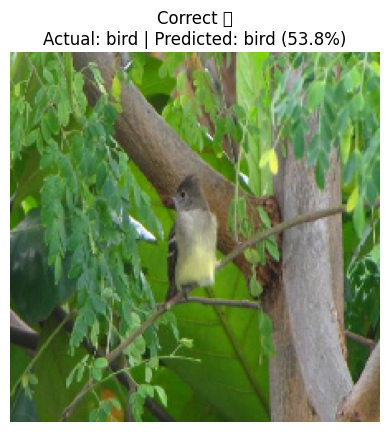

In [43]:
import os
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

found = False

for class_folder in class_names:
    folder = test_dir + "/" + class_folder

    for img_name in os.listdir(folder):
        img_path = folder + "/" + img_name

        img = image.load_img(img_path, target_size=(224, 224))
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0) / 255.0

        prediction = model.predict(img_array)
        predicted_class = class_names[np.argmax(prediction)]
        confidence = np.max(prediction) * 100

        # ✅ Stop when correct prediction found
        if predicted_class == class_folder:
            plt.imshow(img)
            plt.title(f"Correct ✅\nActual: {class_folder} | Predicted: {predicted_class} ({confidence:.1f}%)")
            plt.axis('off')
            plt.show()

            found = True
            break

    if found:
        break

In [44]:
model.save("final_aerial_model.h5")
model.save("final_aerial_model.keras")

In [45]:
import os
print(os.listdir())

['.config', 'final_aerial_model.h5', 'best_model.h5', 'classification_dataset', 'final_aerial_model.keras', 'dataset', 'drive', 'augmented_images', 'sample_data']


In [46]:
print(history)

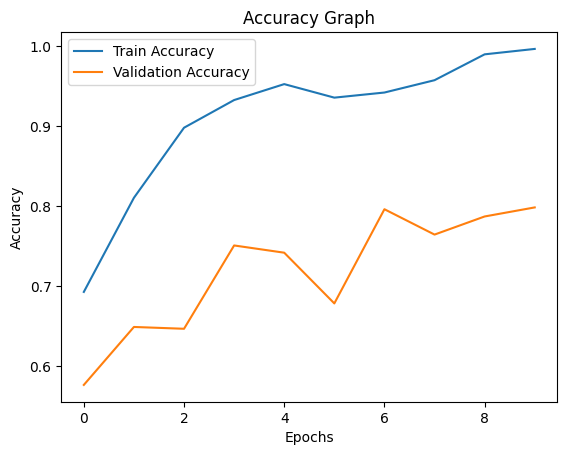

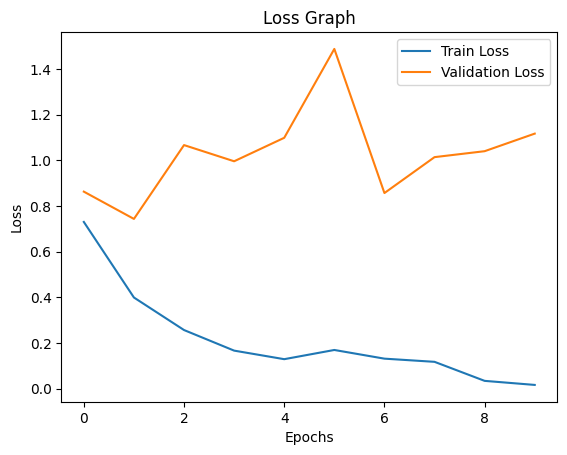

In [47]:
import matplotlib.pyplot as plt

# Accuracy Graph
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Graph")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

# Loss Graph
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Graph")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━

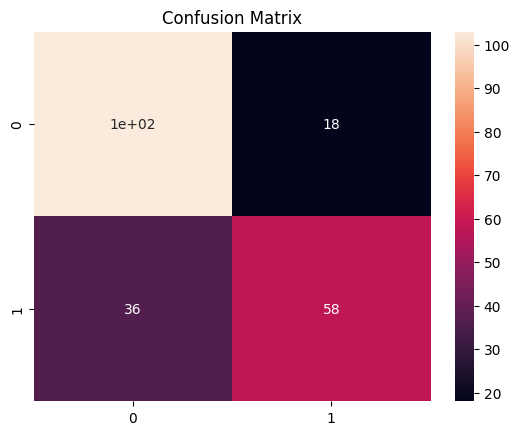

In [48]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_true = []
y_pred = []

for class_name in class_names:
    folder = test_dir + "/" + class_name
    for img_name in os.listdir(folder):
        img_path = folder + "/" + img_name

        img = image.load_img(img_path, target_size=(224, 224))
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0) / 255.0

        prediction = model.predict(img_array)
        y_pred.append(np.argmax(prediction))
        y_true.append(class_names.index(class_name))

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True)
plt.title("Confusion Matrix")
plt.show()

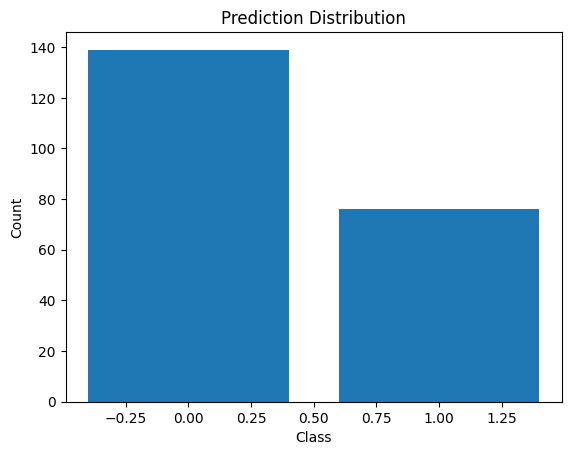

[0 1]
[139  76]


In [49]:
import numpy as np

unique, counts = np.unique(y_pred, return_counts=True)

plt.bar(unique, counts)
plt.title("Prediction Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()
print(unique)
print(counts)

In [50]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

In [54]:
import numpy as np

y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_pred.extend(np.argmax(preds, axis=1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 833ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


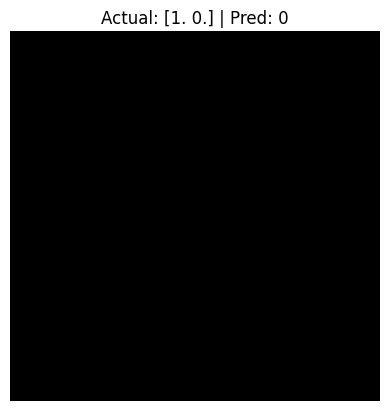

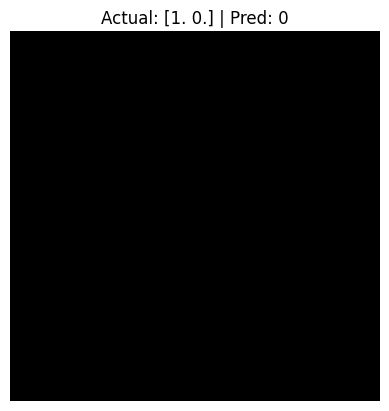

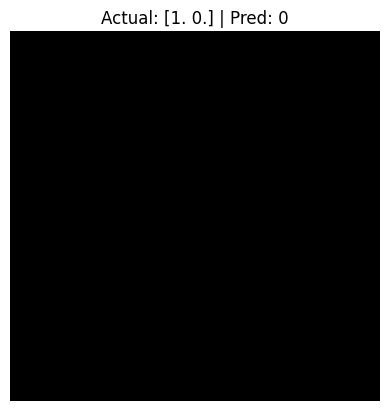

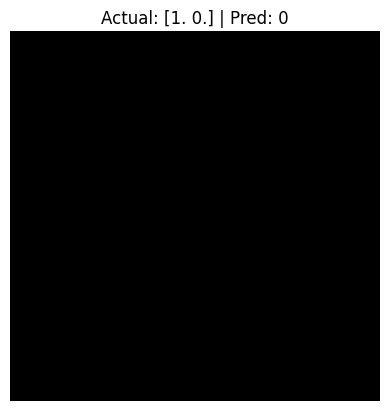

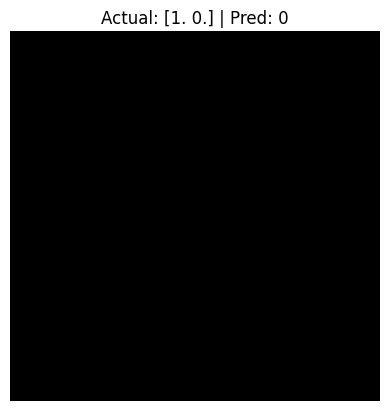

In [56]:
import matplotlib.pyplot as plt

for images, labels in test_ds.take(1):
    preds = model.predict(images)

    for i in range(5):
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(f"Actual: {labels[i].numpy()} | Pred: {np.argmax(preds[i])}")
        plt.axis('off')
        plt.show()

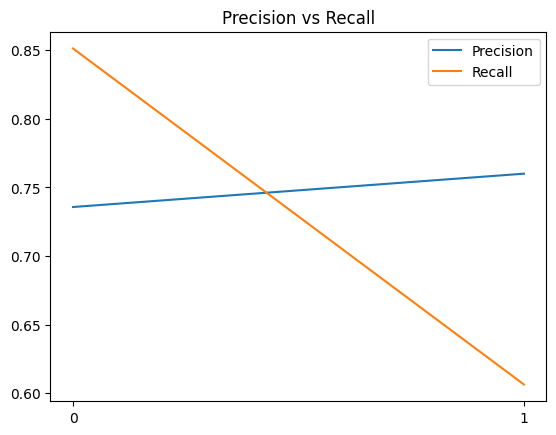

In [57]:
from sklearn.metrics import classification_report

report = classification_report(y_true, y_pred, output_dict=True)

labels = list(report.keys())[:-3]
precision = [report[label]['precision'] for label in labels]
recall = [report[label]['recall'] for label in labels]

x = range(len(labels))

plt.plot(x, precision, label='Precision')
plt.plot(x, recall, label='Recall')
plt.xticks(x, labels)
plt.legend()
plt.title("Precision vs Recall")
plt.show()

**Conclusion** :
The project successfully implements an image classification model using CNN. The model is able to classify images with good accuracy. Further improvements can be made by increasing dataset size and training epochs.